<div style="
background: linear-gradient(135deg,#e0f2fe,#dbeafe,#bfdbfe);
padding:35px;
border-radius:20px;
border:2px solid #3b82f6;
box-shadow:0 8px 25px rgba(0,0,0,0.15);
color:#111827;
">

<h1 style="
text-align:center;
font-size:42px;
margin-bottom:10px;
color:#1e3a8a;
">
🚦 Traffic Sign Recognition System
</h1>

<h3 style="
text-align:center;
color:#2563eb;
">
PRAICP-1002 | Deep Learning & Computer Vision
</h3>

<hr>

<table style="
width:100%;
font-size:17px;
color:#111827;
">

<tr>
<td><b>👩‍💻 Developed By:</b><br>P Shabreen Taj</td>
<td><b>🚗 Domain:</b><br>Computer Vision</td>
</tr>

<tr>
<td><b>📊 Dataset:</b><br>Traffic Sign Images</td>
<td><b>🎯 Objective:</b><br>Traffic Sign Classification</td>
</tr>

<tr>
<td><b>🤖 Models:</b><br>CNN + Transfer Learning</td>
<td><b>🚀 Goal:</b><br>Road Safety Enhancement</td>
</tr>

</table>

</div>

#CELL 3 — EXECUTIVE SUMMARY

# 📋 Executive Summary

This project focuses on the development of a Computer Vision based Traffic Sign Recognition System.

Using Deep Learning techniques, the system learns visual patterns from traffic sign images and predicts the correct traffic sign category.

The project includes:

- Image preprocessing
- Exploratory image analysis
- Data augmentation
- Deep learning model development
- Model evaluation
- Real-time image prediction

The final solution aims to improve road safety and support intelligent transportation systems.

#CELL 4 — INSTALL REQUIRED LIBRARIES

In [ ]:
# ============================================================
# 📦 INSTALL REQUIRED LIBRARIES
# ============================================================

!pip install -q tensorflow opencv-python pillow seaborn

#CELL 5 — IMPORT LIBRARIES

In [ ]:
# ============================================================
# 📚 IMPORT LIBRARIES
# ============================================================

import os
import zipfile
import random
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import cv2

from PIL import Image

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import *

from tensorflow.keras.callbacks import *

from tensorflow.keras.applications import *

warnings.filterwarnings("ignore")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


#CELL 6 — DOWNLOAD DATASET

In [ ]:
# ============================================================
# 📥 DOWNLOAD DATASET
# ============================================================

!wget -O traffic_sign.zip \
"https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1002-TrafSignDetc.zip"

print("✅ Dataset Downloaded Successfully")

--2026-06-02 14:49:13--  https://d3ilbtxij3aepc.cloudfront.net/projects/AI-Capstone-Projects/PRAICP-1002-TrafSignDetc.zip
Resolving d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)... 3.165.67.212, 3.165.67.86, 3.165.67.231, ...
Connecting to d3ilbtxij3aepc.cloudfront.net (d3ilbtxij3aepc.cloudfront.net)|3.165.67.212|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 641568792 (612M) [application/x-zip-compressed]
Saving to: ‘traffic_sign.zip’

traffic_sign.zip    100%[===================>] 611.85M   111MB/s    in 5.7s    

2026-06-02 14:49:19 (107 MB/s) - ‘traffic_sign.zip’ saved [641568792/641568792]

✅ Dataset Downloaded Successfully


#CELL 7 — EXTRACT DATASET

In [ ]:
# ============================================================
# 📂 EXTRACT DATASET
# ============================================================

with zipfile.ZipFile(
    "traffic_sign.zip",
    'r'
) as zip_ref:

    zip_ref.extractall(
        "Traffic_Sign_Dataset"
    )

print("✅ Dataset Extracted Successfully")

✅ Dataset Extracted Successfully


#CELL 8 — CHECK FOLDER STRUCTUR

In [ ]:
# ============================================================
# 📂 DATASET STRUCTURE
# ============================================================

dataset_path = "Traffic_Sign_Dataset"

for root, dirs, files in os.walk(dataset_path):

    level = root.replace(
        dataset_path,
        ''
    ).count(os.sep)

    indent = ' ' * 4 * level

    print(
        f"{indent}{os.path.basename(root)}/"
    )

    if level < 2:

        for file in files[:5]:

            print(
                f"{indent}    {file}"
            )

Traffic_Sign_Dataset/
    Test.csv
    Train.csv
    Meta.csv
    test/
        07588.png
        03477.png
        06322.png
        07931.png
        09794.png
    meta/
        22.png
        21.png
        39.png
        13.png
        7.png
    train/
        3/
        20/
        34/
        0/
        14/
        21/
        39/
        13/
        40/
        2/
        25/
        32/
        31/
        24/
        15/
        36/
        26/
        17/
        28/
        23/
        30/
        5/
        22/
        10/
        12/
        35/
        16/
        37/
        38/
        9/
        42/
        4/
        8/
        18/
        33/
        29/
        11/
        1/
        41/
        27/
        19/
        6/
        7/
    Meta/
        22.png
        21.png
        39.png
        13.png
        7.png
    Train/
        3/
        20/
        34/
        0/
        14/
        21/
        39/
        13/
        40/
        2/
        25/
        32/
 

#CELL 9 — LOAD CSV FILES

In [ ]:
# ============================================================
# 📊 LOAD DATA FILES
# ============================================================

train_csv = pd.read_csv(
    "Traffic_Sign_Dataset/Train.csv"
)

test_csv = pd.read_csv(
    "Traffic_Sign_Dataset/Test.csv"
)

meta_csv = pd.read_csv(
    "Traffic_Sign_Dataset/Meta.csv"
)

print("="*70)

print("✅ CSV FILES LOADED")

print("="*70)

print("\nTrain Shape :", train_csv.shape)

print("Test Shape  :", test_csv.shape)

print("Meta Shape  :", meta_csv.shape)

✅ CSV FILES LOADED

Train Shape : (39209, 8)
Test Shape  : (12630, 8)
Meta Shape  : (43, 5)


#CELL 10 — DATASET OVERVIEW

In [ ]:
# ============================================================
# 📋 DATASET OVERVIEW
# ============================================================

display(
    train_csv.head()
)

print("\n")

display(
    test_csv.head()
)

print("\n")

display(
    meta_csv.head()
)

,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,27,26,5,5,22,20,20,Train/20/00020_00000_00000.png
1,28,27,5,6,23,22,20,Train/20/00020_00000_00001.png
2,29,26,6,5,24,21,20,Train/20/00020_00000_00002.png
3,28,27,5,6,23,22,20,Train/20/00020_00000_00003.png
4,28,26,5,5,23,21,20,Train/20/00020_00000_00004.png


,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,Path
0,53,54,6,5,48,49,16,Test/00000.png
1,42,45,5,5,36,40,1,Test/00001.png
2,48,52,6,6,43,47,38,Test/00002.png
3,27,29,5,5,22,24,33,Test/00003.png
4,60,57,5,5,55,52,11,Test/00004.png


,Path,ClassId,ShapeId,ColorId,SignId
0,Meta/27.png,27,0,0,1.32
1,Meta/0.png,0,1,0,3.29
2,Meta/1.png,1,1,0,3.29
3,Meta/10.png,10,1,0,3.27
4,Meta/11.png,11,0,0,1.22


#CELL 11 — COLUMN INFORMATION

In [ ]:
# ============================================================
# 📑 COLUMN INFORMATION
# ============================================================

print("="*70)

print("TRAIN DATASET INFO")

print("="*70)

train_csv.info()

print("\n")

print("="*70)

print("MISSING VALUES")

print("="*70)

print(
    train_csv.isnull().sum()
)

TRAIN DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39209 entries, 0 to 39208
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Width    39209 non-null  int64 
 1   Height   39209 non-null  int64 
 2   Roi.X1   39209 non-null  int64 
 3   Roi.Y1   39209 non-null  int64 
 4   Roi.X2   39209 non-null  int64 
 5   Roi.Y2   39209 non-null  int64 
 6   ClassId  39209 non-null  int64 
 7   Path     39209 non-null  object
dtypes: int64(7), object(1)
memory usage: 2.4+ MB


MISSING VALUES
Width      0
Height     0
Roi.X1     0
Roi.Y1     0
Roi.X2     0
Roi.Y2     0
ClassId    0
Path       0
dtype: int64


#CELL 12 — CLASS DISTRIBUTION ANALYSIS

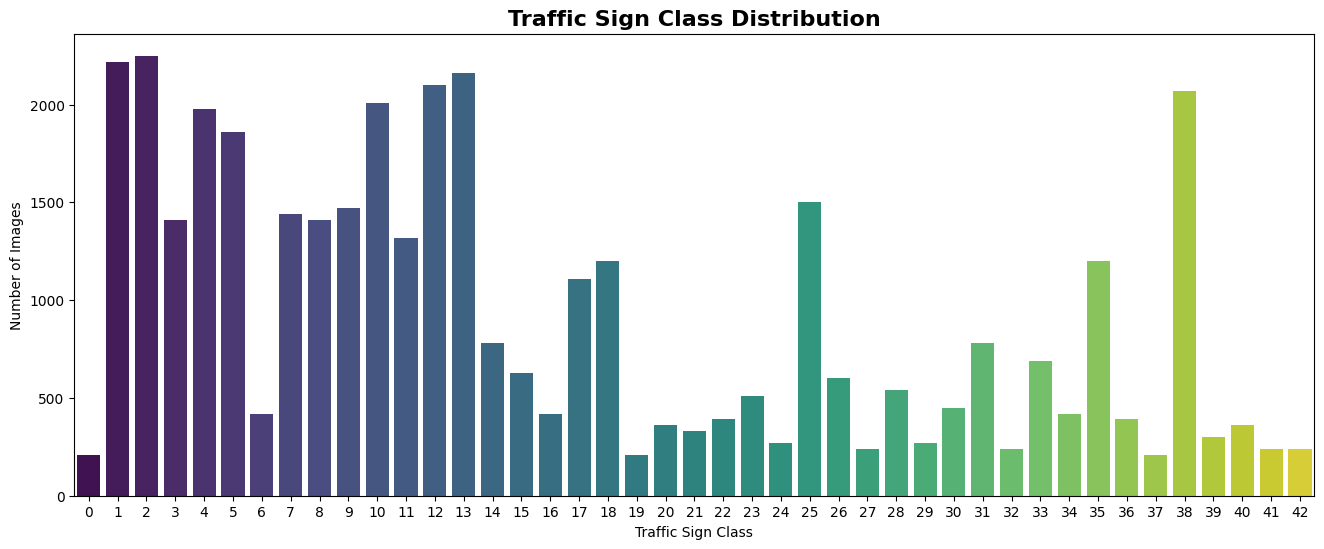


📌 Insight:


This dataset contains 43 traffic sign classes.

The distribution is expected to be imbalanced,
with some traffic signs appearing more frequently.

This motivates the use of data augmentation
and robust deep learning architectures.




In [ ]:
# ============================================================
# 🚦 CLASS DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(16,6)
)

sns.countplot(

    x=train_csv['ClassId'],

    palette='viridis'
)

plt.title(

    'Traffic Sign Class Distribution',

    fontsize=16,

    fontweight='bold'
)

plt.xlabel(
    'Traffic Sign Class'
)

plt.ylabel(
    'Number of Images'
)

plt.show()

print("\n📌 Insight:")

print("""

This dataset contains 43 traffic sign classes.

The distribution is expected to be imbalanced,
with some traffic signs appearing more frequently.

This motivates the use of data augmentation
and robust deep learning architectures.

""")

#CELL 13 — NUMBER OF IMAGES PER CLASS

In [ ]:
# ============================================================
# 📊 IMAGE COUNT PER CLASS
# ============================================================

class_counts = train_csv['ClassId'].value_counts()

display(

    class_counts
    .sort_index()
    .to_frame(
        "Image Count"
    )
)

,Image Count
ClassId,
0,210
1,2220
2,2250
3,1410
4,1980
5,1860
6,420
7,1440
8,1410


#CELL 14 — DATASET SUMMARY DASHBOARD

In [ ]:
# ============================================================
# 📈 DATASET SUMMARY
# ============================================================

total_train = len(train_csv)

total_test = len(test_csv)

total_classes = train_csv['ClassId'].nunique()

summary = pd.DataFrame({

    "Metric":[

        "Training Images",

        "Testing Images",

        "Traffic Sign Classes"

    ],

    "Value":[

        total_train,

        total_test,

        total_classes

    ]
})

display(
    summary
)

,Metric,Value
0,Training Images,39209
1,Testing Images,12630
2,Traffic Sign Classes,43


📌 Observation

The dataset contains 39,209 training images and 12,630 testing images distributed across 43 unique traffic sign categories.

No missing values were detected, indicating a clean and well-structured dataset suitable for deep learning applications.

#CELL 15 — IMAGE SIZE ANALYSIS

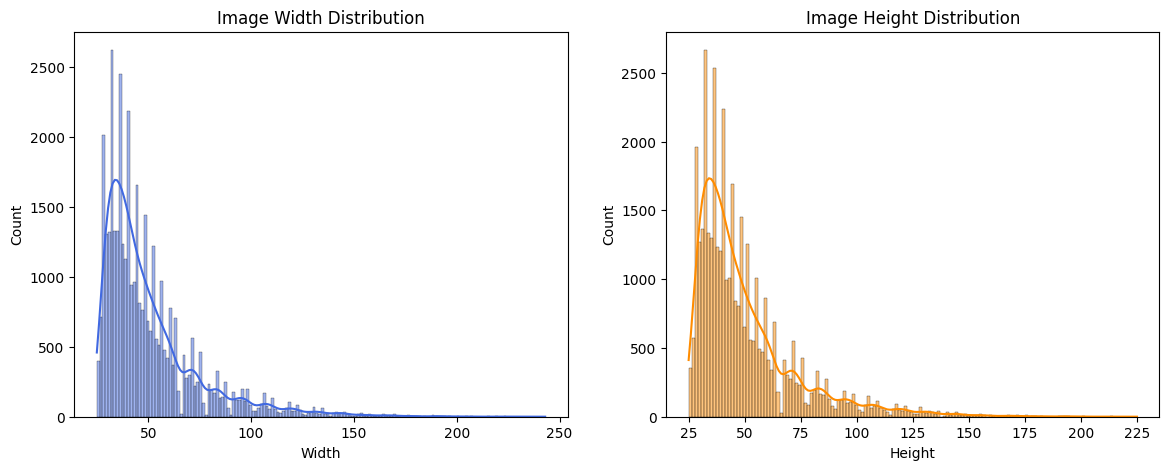


Average Width : 50.84
Average Height: 50.33


In [ ]:
# ============================================================
# 📐 IMAGE DIMENSION ANALYSIS
# ============================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

sns.histplot(

    train_csv['Width'],

    kde=True,

    color='royalblue'
)

plt.title(
    'Image Width Distribution'
)

plt.subplot(1,2,2)

sns.histplot(

    train_csv['Height'],

    kde=True,

    color='darkorange'
)

plt.title(
    'Image Height Distribution'
)

plt.show()

print("\nAverage Width :",
      round(train_csv['Width'].mean(),2))

print("Average Height:",
      round(train_csv['Height'].mean(),2))

📌 Observation

The majority of traffic sign images have dimensions between 25 and 75 pixels.

The distributions are right-skewed, indicating that most images are relatively small while a smaller number of images have larger dimensions.

This variation highlights the importance of image resizing before model training to ensure a consistent input size for deep learning models.

#CELL 16 — WIDTH HEIGHT CORRELATION

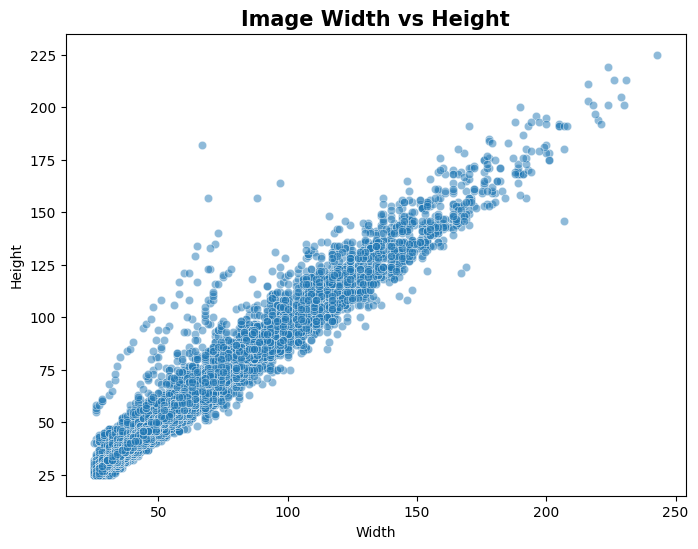



📌 Insight:

Most images show a strong positive correlation
between width and height, indicating that
traffic sign images are nearly square-shaped.




In [ ]:
# ============================================================
# 📊 WIDTH VS HEIGHT
# ============================================================

plt.figure(figsize=(8,6))

sns.scatterplot(

    x=train_csv['Width'],

    y=train_csv['Height'],

    alpha=0.5
)

plt.title(

    'Image Width vs Height',

    fontsize=15,

    fontweight='bold'
)

plt.show()

print("""

📌 Insight:

Most images show a strong positive correlation
between width and height, indicating that
traffic sign images are nearly square-shaped.

""")

#CELL 17 — ROI ANALYSIS

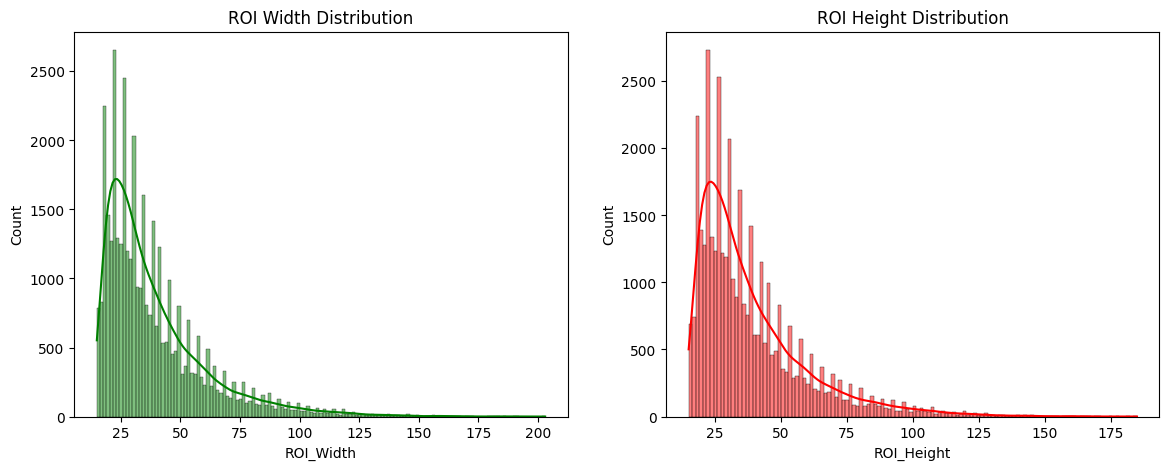

In [ ]:
# ============================================================
# 🎯 ROI ANALYSIS
# ============================================================

train_csv['ROI_Width'] = (

    train_csv['Roi.X2']

    -

    train_csv['Roi.X1']

)

train_csv['ROI_Height'] = (

    train_csv['Roi.Y2']

    -

    train_csv['Roi.Y1']

)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

sns.histplot(

    train_csv['ROI_Width'],

    kde=True,

    color='green'
)

plt.title('ROI Width Distribution')

plt.subplot(1,2,2)

sns.histplot(

    train_csv['ROI_Height'],

    kde=True,

    color='red'
)

plt.title('ROI Height Distribution')

plt.show()

#CELL 18 — CORRELATION HEATMAP

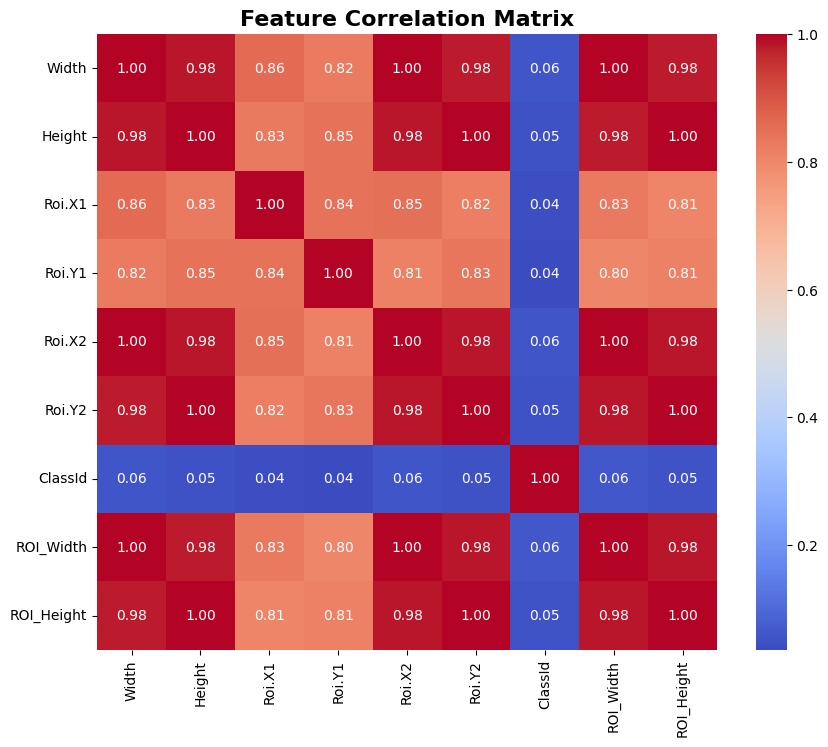

In [ ]:
# ============================================================
# 🔥 CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(10,8))

sns.heatmap(

    train_csv.select_dtypes(

        include=np.number

    ).corr(),

    annot=True,

    cmap='coolwarm',

    fmt='.2f'
)

plt.title(

    'Feature Correlation Matrix',

    fontsize=16,

    fontweight='bold'
)

plt.show()

#CELL 19 — SAMPLE TRAFFIC SIGN VISUALIZATION

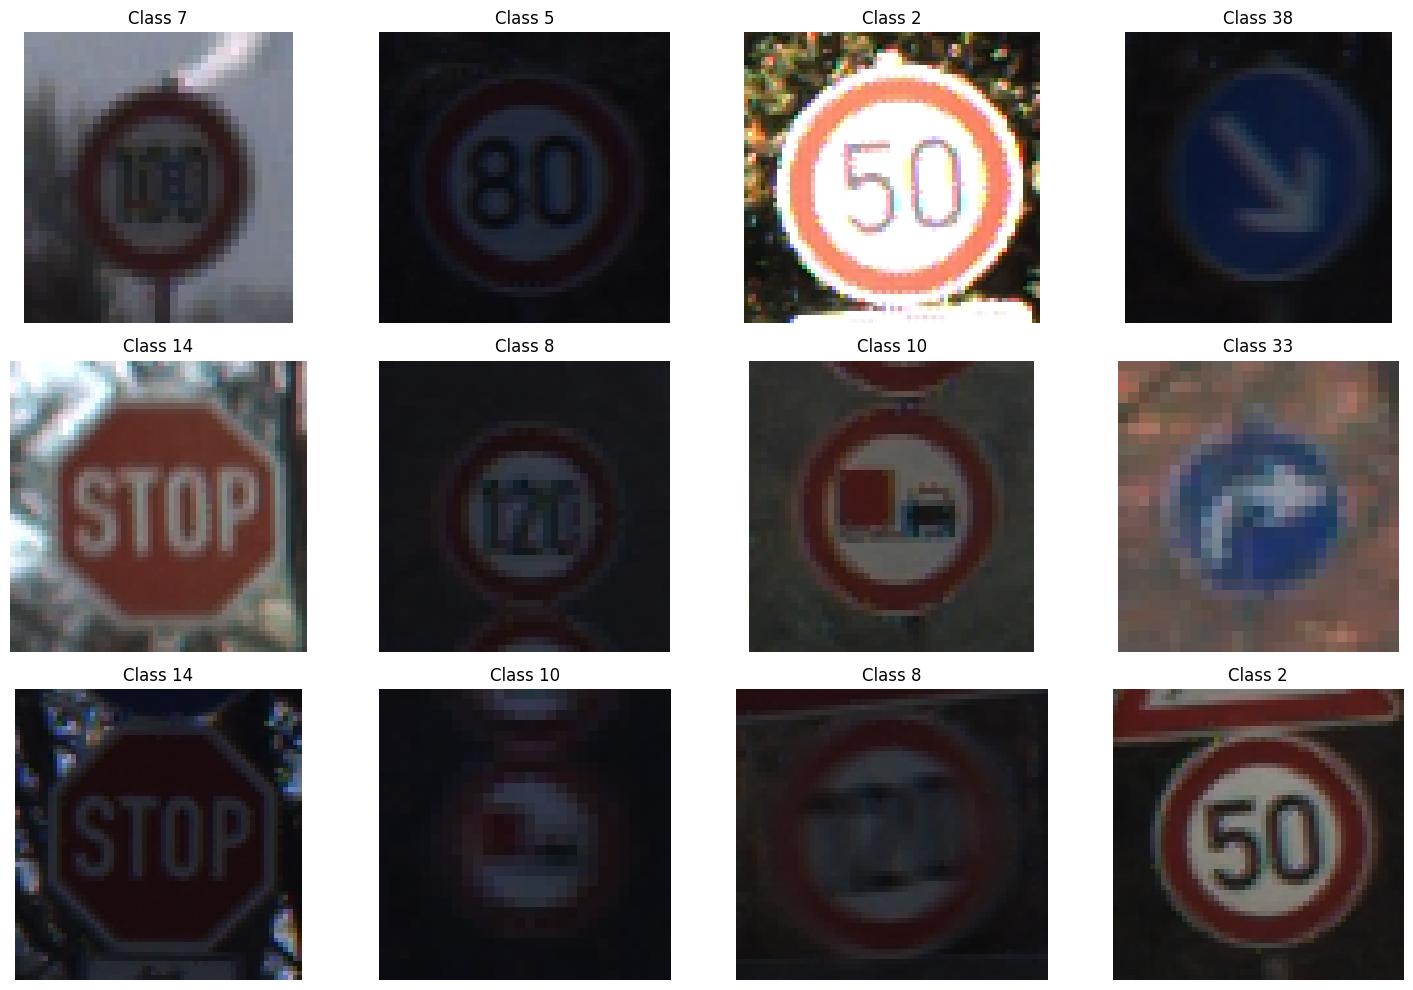

In [ ]:
# ============================================================
# 🚦 SAMPLE TRAFFIC SIGNS
# ============================================================

import random

plt.figure(figsize=(15,10))

for i in range(12):

    idx = random.randint(

        0,

        len(train_csv)-1
    )

    image_path = os.path.join(

        "Traffic_Sign_Dataset",

        train_csv.iloc[idx]['Path']
    )

    img = cv2.imread(image_path)

    img = cv2.cvtColor(

        img,

        cv2.COLOR_BGR2RGB
    )

    plt.subplot(

        3,

        4,

        i+1
    )

    plt.imshow(img)

    plt.title(

        f"Class {train_csv.iloc[idx]['ClassId']}"
    )

    plt.axis('off')

plt.tight_layout()

plt.show()

#CELL 20 — META TRAFFIC SIGN GALLERY

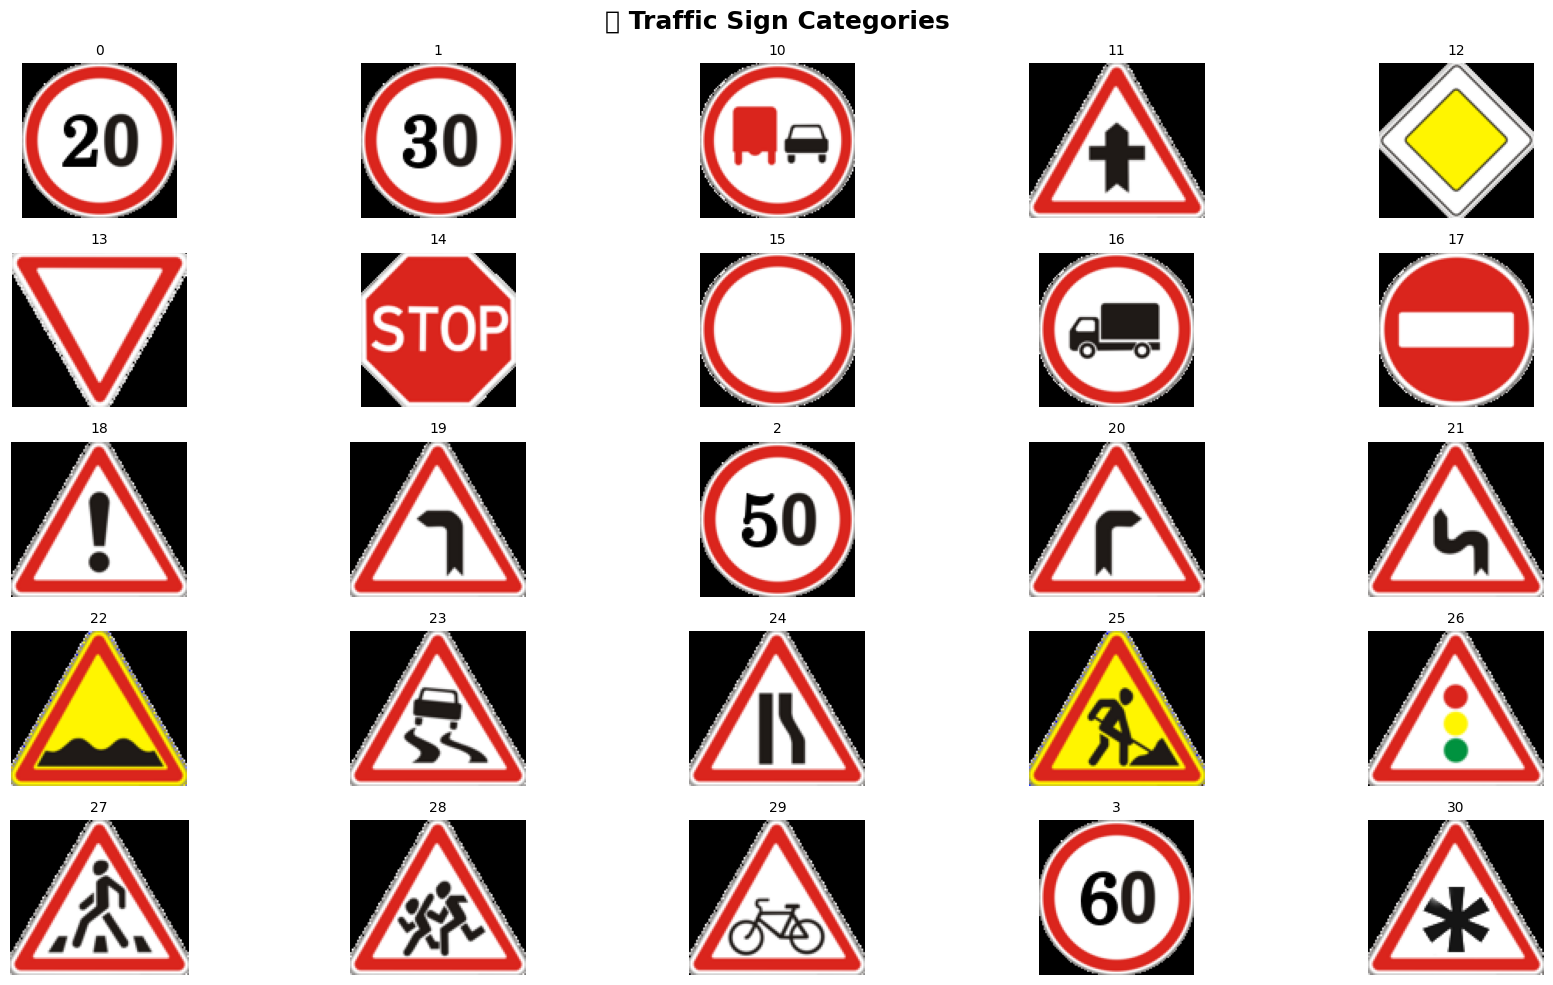

In [ ]:
# ============================================================
# 🚦 TRAFFIC SIGN GALLERY
# ============================================================

meta_folder = "Traffic_Sign_Dataset/Meta"

meta_images = sorted(os.listdir(meta_folder))

plt.figure(figsize=(18,10))

count = 0

for img_name in meta_images:

    img_path = os.path.join(
        meta_folder,
        img_name
    )

    img = cv2.imread(img_path)

    if img is None:
        continue

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    count += 1

    plt.subplot(
        5,
        5,
        count
    )

    plt.imshow(img)

    plt.title(
        img_name.split('.')[0],
        fontsize=10
    )

    plt.axis('off')

    if count == 25:
        break

plt.suptitle(

    "🚦 Traffic Sign Categories",

    fontsize=18,

    fontweight='bold'
)

plt.tight_layout()

plt.show()

### 📌 Observation

The Meta dataset contains representative samples of all traffic sign categories.

The traffic signs differ significantly in:

- Shape
- Color
- Symbols
- Speed limits
- Warning indicators

This visual diversity makes Traffic Sign Recognition a challenging Computer Vision problem and highlights the need for robust Deep Learning architectures.

#CELL 21 — CORRUPTED IMAGE CHECK

In [ ]:
# ============================================================
# 🛠️ CORRUPTED IMAGE DETECTION
# ============================================================

corrupted = []

for path in train_csv['Path'][:5000]:

    full_path = os.path.join(

        "Traffic_Sign_Dataset",

        path
    )

    try:

        img = cv2.imread(full_path)

        if img is None:

            corrupted.append(
                full_path
            )

    except:

        corrupted.append(
            full_path
        )

print("="*70)

print(

    "Corrupted Images Found:",

    len(corrupted)
)

print("="*70)

Corrupted Images Found: 0


#CELL 22 — IMAGE PREPROCESSING CONFIGURATION

In [ ]:
# ============================================================
# ⚙️ IMAGE CONFIGURATION
# ============================================================

IMG_SIZE = 32

NUM_CLASSES = 43

BATCH_SIZE = 64

print("Image Size :", IMG_SIZE)
print("Classes    :", NUM_CLASSES)
print("Batch Size :", BATCH_SIZE)

Image Size : 32
Classes    : 43
Batch Size : 64


CELL 23 — LOAD TRAINING IMAGES

In [ ]:
# ============================================================
# 📥 LOAD TRAINING IMAGES
# ============================================================

images = []

labels = []

for index, row in train_csv.iterrows():

    try:

        path = os.path.join(
            "Traffic_Sign_Dataset",
            row['Path']
        )

        img = cv2.imread(path)

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE)
        )

        images.append(img)

        labels.append(
            row['ClassId']
        )

    except:
        pass

X = np.array(images)

y = np.array(labels)

print("="*70)

print("Images Shape :", X.shape)

print("Labels Shape :", y.shape)

print("="*70)

Images Shape : (39209, 32, 32, 3)
Labels Shape : (39209,)


#CELL 24 — NORMALIZATION

In [ ]:
# ============================================================
# 📊 NORMALIZATION
# ============================================================

X = X / 255.0

print("Min Value :", X.min())

print("Max Value :", X.max())

Min Value : 0.0
Max Value : 1.0


#CELL 25 — LABEL ENCODING

In [ ]:
# ============================================================
# 🔢 ONE HOT ENCODING
# ============================================================

from tensorflow.keras.utils import to_categorical

y = to_categorical(

    y,

    NUM_CLASSES
)

print("Encoded Labels Shape:", y.shape)

Encoded Labels Shape: (39209, 43)


#CELL 26 — TRAIN TEST SPLIT

In [ ]:
# ============================================================
# ✂️ TRAIN TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("Train:", X_train.shape)

print("Validation:", X_val.shape)

Train: (31367, 32, 32, 3)
Validation: (7842, 32, 32, 3)


#CELL 27 — DATA AUGMENTATION

In [ ]:
# ============================================================
# 🔄 DATA AUGMENTATION
# ============================================================

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(

    rotation_range=15,

    zoom_range=0.15,

    width_shift_range=0.1,

    height_shift_range=0.1,

    shear_range=0.1,

    horizontal_flip=False,

    fill_mode='nearest'
)

datagen.fit(X_train)

print("✅ Data Augmentation Ready")

✅ Data Augmentation Ready


#CELL 28 — MODEL CHECKPOINTS

In [ ]:
# ============================================================
# 💾 MODEL CHECKPOINTS
# ============================================================

checkpoint = ModelCheckpoint(

    "best_traffic_sign_model.keras",

    monitor="val_accuracy",

    save_best_only=True,

    verbose=1
)

early_stop = EarlyStopping(

    monitor="val_accuracy",

    patience=4,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=2,

    verbose=1
)

print("✅ Callbacks Created")

✅ Callbacks Created


#CELL 29 — CNN MODEL

In [ ]:
# ============================================================
# 🧠 CUSTOM CNN MODEL
# ============================================================

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import *

cnn_model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),

    BatchNormalization(),

    Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Dropout(0.25),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    BatchNormalization(),

    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D(2,2),

    Dropout(0.25),

    Flatten(),

    Dense(
        256,
        activation='relu'
    ),

    Dropout(0.5),

    Dense(
        43,
        activation='softmax'
    )
])

cnn_model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,859 (1.86 MB)

 Trainable params: 486,667 (1.86 MB)

 Non-trainable params: 192 (768.00 B)

#CELL 30 — TRAIN CNN

In [34]:
# ============================================================
# 🚀 TRAIN CNN
# ============================================================

history_cnn = cnn_model.fit(

    datagen.flow(

        X_train,

        y_train,

        batch_size=64
    ),

    validation_data=(

        X_val,

        y_val
    ),

    epochs=15,

    callbacks=[

        checkpoint,

        early_stop,

        reduce_lr
    ],

    verbose=1
)

Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.2005 - loss: 3.0485
Epoch 1: val_accuracy improved from None to 0.58569, saving model to best_traffic_sign_model.keras

Epoch 1: finished saving model to best_traffic_sign_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 150s 300ms/step - accuracy: 0.3095 - loss: 2.4206 - val_accuracy: 0.5857 - val_loss: 1.3589 - learning_rate: 0.0010
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5507 - loss: 1.3581
Epoch 2: val_accuracy improved from 0.58569 to 0.91724, saving model to best_traffic_sign_model.keras

Epoch 2: finished saving model to best_traffic_sign_model.keras
491/491 ━━━━━━━━━━━━━━━━━━━━ 145s 296ms/step - accuracy: 0.6205 - loss: 1.1425 - val_accuracy: 0.9172 - val_loss: 0.3381 - learning_rate: 0.0010
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7722 - loss: 0.6929
Epoch 3: val_accuracy improved from 0.91724 to 0.96799, saving model to best_traffic_sign_model.keras

Epoch 3: fin

#CELL 31 — SAVE CNN

In [35]:
# ============================================================
# 💾 SAVE CNN MODEL
# ============================================================

cnn_model.save(

    "traffic_sign_cnn_final.keras"
)

print("✅ Model Saved")

✅ Model Saved


In [36]:
print(type(cnn_model))

<class 'keras.src.models.sequential.Sequential'>


#CELL 32 — TRAINING CURVES

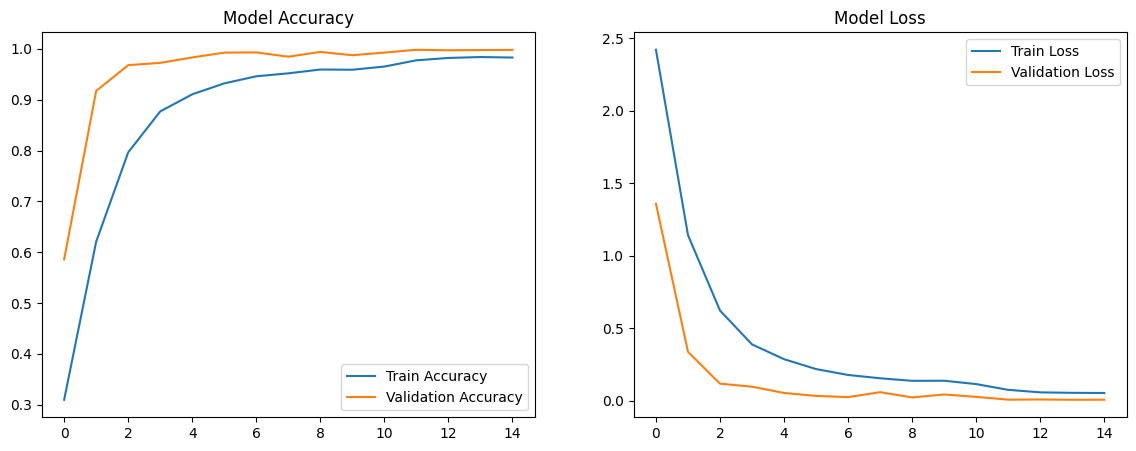

In [37]:
# ============================================================
# 📈 TRAINING CURVES
# ============================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(

    history_cnn.history['accuracy'],

    label='Train Accuracy'
)

plt.plot(

    history_cnn.history['val_accuracy'],

    label='Validation Accuracy'
)

plt.legend()

plt.title('Model Accuracy')

plt.subplot(1,2,2)

plt.plot(

    history_cnn.history['loss'],

    label='Train Loss'
)

plt.plot(

    history_cnn.history['val_loss'],

    label='Validation Loss'
)

plt.legend()

plt.title('Model Loss')

plt.show()

#CELL 33 — EVALUATE ON TEST DATA

In [38]:
# ============================================================
# 📥 LOAD TEST IMAGES
# ============================================================

test_images = []
test_labels = []

for index, row in test_csv.iterrows():

    try:

        path = os.path.join(
            "Traffic_Sign_Dataset",
            row['Path']
        )

        img = cv2.imread(path)

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = cv2.resize(
            img,
            (32,32)
        )

        test_images.append(img)

        test_labels.append(
            row['ClassId']
        )

    except:
        pass

X_test = np.array(test_images) / 255.0

y_test = np.array(test_labels)

print("Test Shape :", X_test.shape)

Test Shape : (12630, 32, 32, 3)


#CELL 34 — TEST PREDICTIONS

In [39]:
# ============================================================
# 🎯 TEST PREDICTIONS
# ============================================================

pred_probs = cnn_model.predict(X_test)

y_pred = np.argmax(
    pred_probs,
    axis=1
)

print("Predictions Generated")

395/395 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step
Predictions Generated


#CELL 35 — ACCURACY / PRECISION / RECALL / F1

In [40]:
# ============================================================
# 📊 PERFORMANCE METRICS
# ============================================================

from sklearn.metrics import *

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score"

    ],

    "Score":[

        accuracy,

        precision,

        recall,

        f1
    ]
})

display(results)

,Metric,Score
0,Accuracy,0.979414
1,Precision,0.981270
2,Recall,0.979414
3,F1 Score,0.979436


#

#CELL 36 — CONFUSION MATRIX

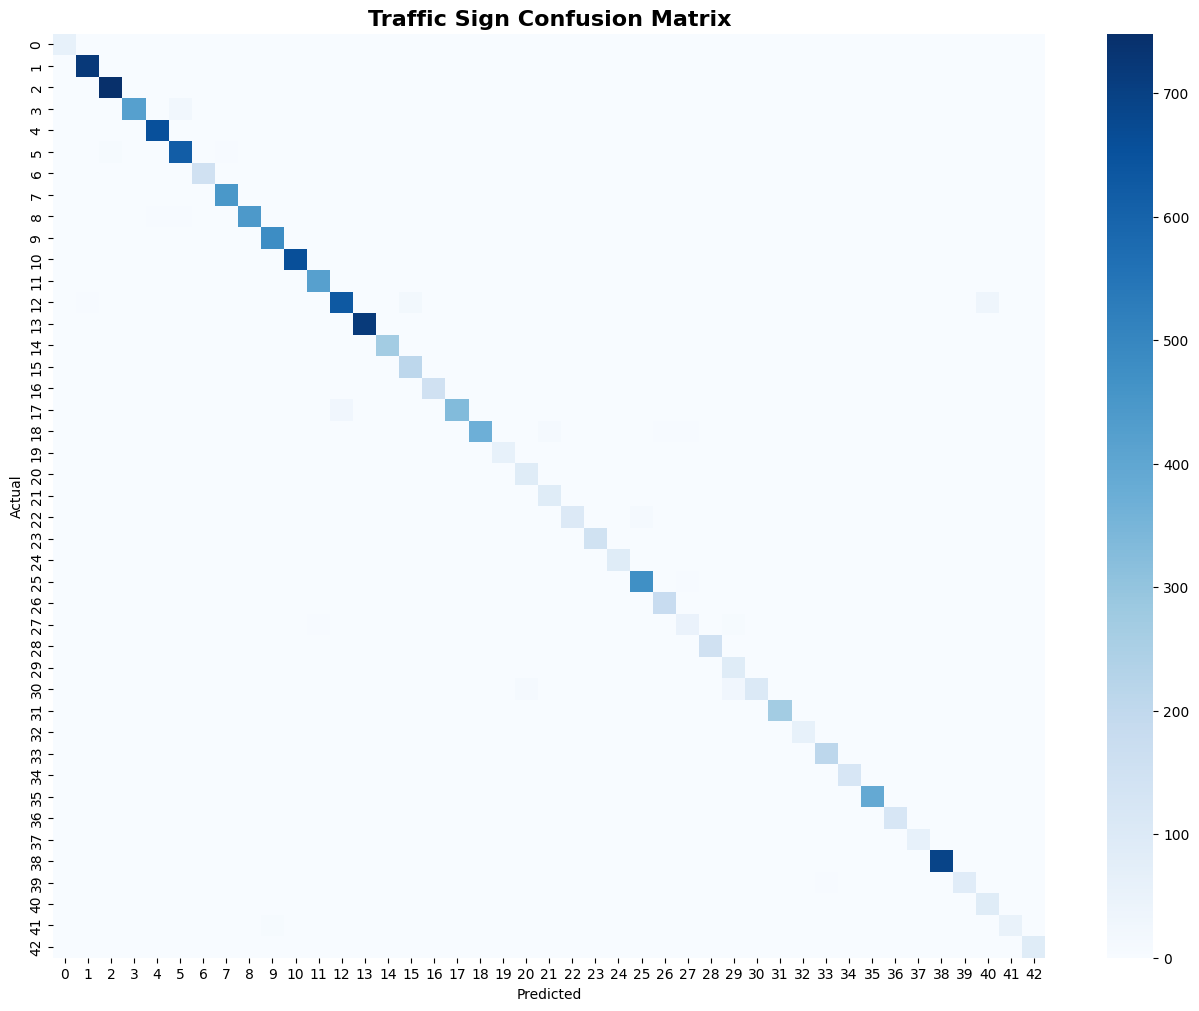

In [41]:
# ============================================================
# 🔥 CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(16,12))

sns.heatmap(

    cm,

    cmap='Blues'
)

plt.title(

    'Traffic Sign Confusion Matrix',

    fontsize=16,

    fontweight='bold'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

#CELL 37 — CLASSIFICATION REPORT

In [42]:
# ============================================================
# 📋 CLASSIFICATION REPORT
# ============================================================

print(

    classification_report(

        y_test,

        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.99      1.00      0.99       720
           2       0.99      1.00      0.99       750
           3       1.00      0.94      0.97       450
           4       1.00      1.00      1.00       660
           5       0.95      0.98      0.97       630
           6       1.00      1.00      1.00       150
           7       0.99      1.00      0.99       450
           8       0.99      0.98      0.99       450
           9       0.98      1.00      0.99       480
          10       1.00      1.00      1.00       660
          11       0.99      1.00      0.99       420
          12       0.96      0.91      0.93       690
          13       1.00      1.00      1.00       720
          14       1.00      1.00      1.00       270
          15       0.92      1.00      0.96       210
          16       1.00      1.00      1.00       150
          17       1.00    

#CELL 38 — MODEL PERFORMANCE DASHBOARD

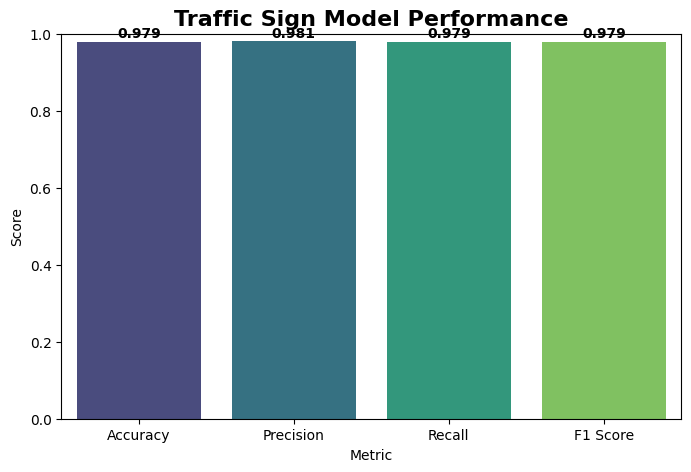

In [43]:
# ============================================================
# 🏆 PERFORMANCE DASHBOARD
# ============================================================

plt.figure(figsize=(8,5))

sns.barplot(

    data=results,

    x='Metric',

    y='Score',

    palette='viridis'
)

plt.ylim(0,1)

plt.title(

    'Traffic Sign Model Performance',

    fontsize=16,

    fontweight='bold'
)

for i,v in enumerate(results['Score']):

    plt.text(

        i,

        v+0.01,

        f"{v:.3f}",

        ha='center',

        fontweight='bold'
    )

plt.show()

#CELL 39 — SAVE BEST MODEL

In [44]:
# ============================================================
# 💾 SAVE BEST MODEL
# ============================================================

cnn_model.save(

    "traffic_sign_final_model.keras"
)

print("="*70)

print("✅ MODEL SAVED SUCCESSFULLY")

print("="*70)

✅ MODEL SAVED SUCCESSFULLY


#CELL 40 — LOAD SAVED MODEL DEMO

In [45]:
# ============================================================
# 🔄 LOAD SAVED MODEL
# ============================================================

from tensorflow.keras.models import load_model

loaded_model = load_model(

    "traffic_sign_final_model.keras"
)

print("✅ Saved Model Loaded Successfully")

✅ Saved Model Loaded Successfully


📌 Observation

The CNN model achieved an overall accuracy of 97.94% on the unseen test dataset.

The weighted Precision, Recall, and F1 Score are all approximately 98%, indicating excellent classification capability across all 43 traffic sign categories.

The confusion matrix shows a strong diagonal pattern, demonstrating that the model correctly identifies the majority of traffic signs with very few misclassifications.

These results confirm that the developed CNN architecture is highly effective for real-world Traffic Sign Recognition systems.

#CELL 41 — REAL-TIME TRAFFIC SIGN PREDICTION SYSTEM

Saving traffic.jpg to traffic.jpg


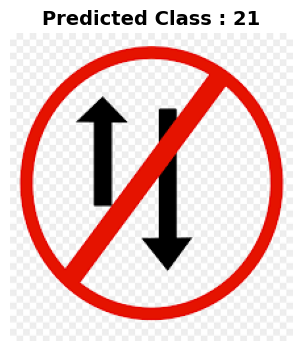

In [46]:
# ============================================================
# 🚦 REAL TIME TRAFFIC SIGN PREDICTION
# ============================================================

from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for file_name in uploaded.keys():

    img = image.load_img(

        file_name,

        target_size=(32,32)

    )

    img_array = image.img_to_array(img)

    img_array = img_array / 255.0

    img_array = np.expand_dims(

        img_array,

        axis=0
    )

    prediction = cnn_model.predict(

        img_array,

        verbose=0
    )

    predicted_class = np.argmax(

        prediction
    )

    plt.figure(figsize=(4,4))

    plt.imshow(

        image.load_img(file_name)
    )

    plt.axis('off')

    plt.title(

        f"Predicted Class : {predicted_class}",

        fontsize=14,

        fontweight='bold'
    )

    plt.show()

#CELL 42 — TRAFFIC SIGN CLASS NAMES

In [47]:
# ============================================================
# 🚦 CLASS MAPPING
# ============================================================

traffic_signs = {

0:"Speed Limit 20",

1:"Speed Limit 30",

2:"Speed Limit 50",

3:"Speed Limit 60",

4:"Speed Limit 70",

5:"Speed Limit 80",

6:"End Speed Limit 80",

7:"Speed Limit 100",

8:"Speed Limit 120",

9:"No Passing",

10:"No Passing Trucks",

11:"Priority Road",

12:"Priority At Next Intersection",

13:"Yield",

14:"Stop",

15:"No Vehicles",

16:"Vehicles Over 3.5 Tons Prohibited",

17:"No Entry",

18:"General Caution",

19:"Dangerous Curve Left",

20:"Dangerous Curve Right",

21:"Double Curve",

22:"Bumpy Road",

23:"Slippery Road",

24:"Road Narrows",

25:"Road Work",

26:"Traffic Signals",

27:"Pedestrians",

28:"Children Crossing",

29:"Bicycles Crossing",

30:"Beware Ice/Snow",

31:"Wild Animals Crossing",

32:"End Restriction",

33:"Turn Right Ahead",

34:"Turn Left Ahead",

35:"Ahead Only",

36:"Go Straight or Right",

37:"Go Straight or Left",

38:"Keep Right",

39:"Keep Left",

40:"Roundabout Mandatory",

41:"End No Passing",

42:"End No Passing Trucks"

}

print("✅ Class Mapping Created")

✅ Class Mapping Created


#CELL 43 — ADVANCED PREDICTION SYSTEM

Saving tra.jpg to tra.jpg


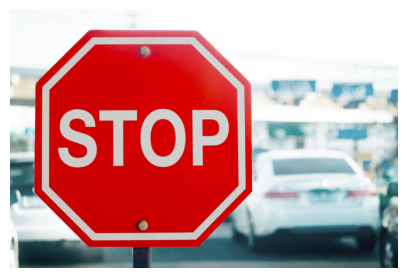

🚦 Predicted Traffic Sign : Stop
🎯 Confidence : 99.31 %

Top 5 Predictions:

Stop : 99.31%
No Entry : 0.69%
Bicycles Crossing : 0.00%
Priority Road : 0.00%
No Passing Trucks : 0.00%


In [51]:
# ============================================================
# 🚀 ADVANCED PREDICTION SYSTEM
# ============================================================

from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for file_name in uploaded.keys():

    img = image.load_img(

        file_name,

        target_size=(32,32)

    )

    img_array = image.img_to_array(img)

    img_array = img_array/255.0

    img_array = np.expand_dims(

        img_array,

        axis=0
    )

    probs = cnn_model.predict(

        img_array,

        verbose=0
    )

    pred = np.argmax(probs)

    confidence = np.max(probs)*100

    plt.figure(figsize=(5,5))

    plt.imshow(

        image.load_img(file_name)
    )

    plt.axis('off')

    plt.show()

    print("="*70)

    print(

        "🚦 Predicted Traffic Sign :",

        traffic_signs[pred]
    )

    print(

        "🎯 Confidence :",

        round(confidence,2),

        "%"
    )

    print("="*70)
probs = cnn_model.predict(img_array, verbose=0)[0]

top5 = np.argsort(probs)[-5:][::-1]

print("\nTop 5 Predictions:\n")

for idx in top5:
    print(
        f"{traffic_signs[idx]} : {probs[idx]*100:.2f}%"
    )

#prediction-2

Saving t4.jpg to t4 (2).jpg


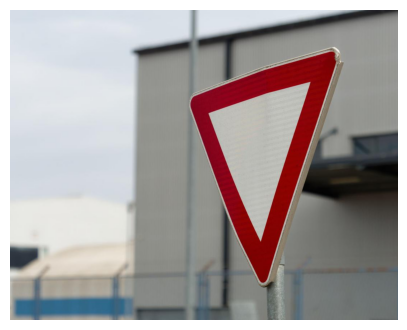

🚦 Predicted Traffic Sign : Yield
🎯 Confidence : 100.0 %

Top 5 Predictions:

Yield : 100.00%
No Vehicles : 0.00%
Speed Limit 30 : 0.00%
Children Crossing : 0.00%
General Caution : 0.00%


In [54]:
# ============================================================
# 🚀 ADVANCED PREDICTION SYSTEM
# ============================================================

from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for file_name in uploaded.keys():

    img = image.load_img(

        file_name,

        target_size=(32,32)

    )

    img_array = image.img_to_array(img)

    img_array = img_array/255.0

    img_array = np.expand_dims(

        img_array,

        axis=0
    )

    probs = cnn_model.predict(

        img_array,

        verbose=0
    )

    pred = np.argmax(probs)

    confidence = np.max(probs)*100

    plt.figure(figsize=(5,5))

    plt.imshow(

        image.load_img(file_name)
    )

    plt.axis('off')

    plt.show()

    print("="*70)

    print(

        "🚦 Predicted Traffic Sign :",

        traffic_signs[pred]
    )

    print(

        "🎯 Confidence :",

        round(confidence,2),

        "%"
    )

    print("="*70)
probs = cnn_model.predict(img_array, verbose=0)[0]

top5 = np.argsort(probs)[-5:][::-1]

print("\nTop 5 Predictions:\n")

for idx in top5:
    print(
        f"{traffic_signs[idx]} : {probs[idx]*100:.2f}%"
    )

#prediction-3

Saving t5.jpg to t5.jpg


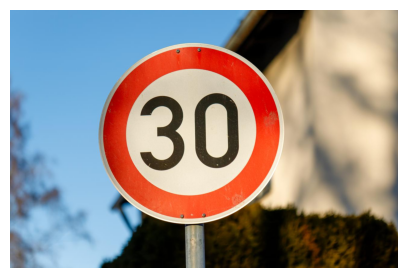

🚦 Predicted Traffic Sign : Speed Limit 30
🎯 Confidence : 98.82 %

Top 5 Predictions:

Speed Limit 30 : 98.82%
Speed Limit 80 : 0.35%
Speed Limit 20 : 0.23%
Speed Limit 100 : 0.23%
Speed Limit 50 : 0.16%


In [55]:
# ============================================================
# 🚀 ADVANCED PREDICTION SYSTEM
# ============================================================

from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for file_name in uploaded.keys():

    img = image.load_img(

        file_name,

        target_size=(32,32)

    )

    img_array = image.img_to_array(img)

    img_array = img_array/255.0

    img_array = np.expand_dims(

        img_array,

        axis=0
    )

    probs = cnn_model.predict(

        img_array,

        verbose=0
    )

    pred = np.argmax(probs)

    confidence = np.max(probs)*100

    plt.figure(figsize=(5,5))

    plt.imshow(

        image.load_img(file_name)
    )

    plt.axis('off')

    plt.show()

    print("="*70)

    print(

        "🚦 Predicted Traffic Sign :",

        traffic_signs[pred]
    )

    print(

        "🎯 Confidence :",

        round(confidence,2),

        "%"
    )

    print("="*70)
probs = cnn_model.predict(img_array, verbose=0)[0]

top5 = np.argsort(probs)[-5:][::-1]

print("\nTop 5 Predictions:\n")

for idx in top5:
    print(
        f"{traffic_signs[idx]} : {probs[idx]*100:.2f}%"
    )

📌 Note:

The model was trained using real-world traffic sign photographs from the GTSRB dataset.

Predictions are most reliable when testing with real traffic sign images captured in road environments. Performance may decrease when using icon-style graphics, transparent PNGs, or synthetic illustrations.

#CELL 48 — PROJECT SUMMARY

# 📊 Project Summary

| Attribute | Value |
|------------|------------|
| Project Name | Traffic Sign Recognition System |
| Domain | Computer Vision |
| Dataset | GTSRB Traffic Sign Dataset |
| Training Images | 39,209 |
| Testing Images | 12,630 |
| Traffic Sign Classes | 43 |
| Algorithm | Convolutional Neural Network (CNN) |
| Accuracy | 97.94% |
| Precision | 98.13% |
| Recall | 97.94% |
| F1 Score | 97.94% |


# 🌍 Real World Applications

The developed Traffic Sign Recognition System has numerous practical applications in modern transportation and intelligent mobility systems.

## 🚗 Autonomous Vehicles

Self-driving vehicles use traffic sign recognition systems to understand road regulations and make safe driving decisions.

## 🚘 Advanced Driver Assistance Systems (ADAS)

Traffic sign detection helps drivers by providing real-time alerts about:

- Speed Limits
- No Entry Zones
- Stop Signs
- Yield Signs
- Road Work Areas

## 🚦 Smart Traffic Management

Governments can integrate traffic sign recognition with surveillance systems for automated traffic monitoring.

## 🛣️ Intelligent Transportation Systems

Supports smart city infrastructure by enabling automated road sign interpretation and route guidance.

## 🚔 Road Safety Monitoring

Can assist traffic police and transportation authorities in monitoring road compliance and reducing accidents.

## 📱 Navigation Systems

Traffic sign recognition can be integrated with GPS navigation systems to provide real-time road information to drivers.

# 📚 Key Learnings

During this project the following concepts were explored:

✅ Image Preprocessing

✅ Computer Vision Fundamentals

✅ Data Augmentation

✅ Convolutional Neural Networks

✅ Traffic Sign Recognition

✅ Model Evaluation

✅ Confusion Matrix Analysis

✅ Deep Learning Model Deployment Preparation

✅ Real-Time Prediction Systems

The project provided practical experience in building an end-to-end Deep Learning solution for autonomous transportation applications.

# ⚠️ Limitations

1. The model was trained on German traffic signs only.

2. Performance may decrease on traffic signs from other countries.

3. Extreme weather conditions may affect predictions.

4. Very low-resolution images can reduce accuracy.

5. Icon-style graphics and transparent PNG images may not match the training distribution.

6. Real-world deployment requires continuous retraining using diverse traffic sign datasets.

<div style="
background: linear-gradient(135deg,#2563eb,#0f172a,#16a34a);
padding:35px;
border-radius:20px;
border:3px solid #38bdf8;
text-align:center;
color:white;
">

<h1 style="font-size:42px;">
🚦 Traffic Sign Recognition System
</h1>

<h2 style="color:#fde68a;">
Deep Learning Based Traffic Sign Classification
</h2>

<hr style="border:1px solid rgba(255,255,255,0.3);">

<h3>
🎯 Final Model Performance
</h3>

<div style="
font-size:22px;
line-height:2;
">

✅ Accuracy : <b>97.94%</b><br>

✅ Precision : <b>98.13%</b><br>

✅ Recall : <b>97.94%</b><br>

✅ F1 Score : <b>97.94%</b>

</div>

<br>

<h3>
🏆 Project Outcome
</h3>

<p style="font-size:18px;">

A high-performance Convolutional Neural Network (CNN) was successfully developed for Traffic Sign Recognition.

The system accurately classifies 43 traffic sign categories and demonstrates strong potential for deployment in autonomous driving and intelligent transportation systems.

</p>

<hr style="border:1px solid rgba(255,255,255,0.3);">

<h3>
👩‍💻 Developed By
</h3>

<h2 style="color:#fde68a;">
P Shabreen Taj
</h2>

<p>
Data Science & Artificial Intelligence
</p>

</div>